# Phase Transition in the 2D Ising Model: A Monte Carlo Study


- **Autor:** Théo HUET
- **Degree:** Master 1 of Physics Thoeric
- **Institution:** University of CY Cergy-Paris Université
- **Course:** Monte Carlo, Alessandro Torcini
- **Date:** March, 2025

In [7]:
import matplotlib.pyplot as plt
import numpy as np


---

## 1. Introduction and Objectives

### Context
The Ising model is a mathematical model of ferromagnetism in statistical mechanics. It describes a system of discrete variables called **spins** ($s_i \in \{-1, +1\}$) arranged on a lattice. While the 1D Ising model does not exhibit a phase transition at non-zero temperatures, the **2D Ising model** on a square lattice undergoes a continuous phase transition at a specific critical temperature $T_c$.

In [8]:
def init_lattice(l) :
    lattice = (2*np.random.randint(0,2,size=(l,l))-1)
    return lattice

Below $T_c$, the system is in an **ordered state** where spins align spontaneously (ferromagnetism). Above $T_c$, thermal fluctuations dominate, leading to a **disordered state** (paramagnetism).

### Project Goals
The objective of this project is to simulate the 2D Ising model using stochastic methods to observe this transition. We aim to:
* Implement the **Metropolis-Hastings algorithm** to sample configurations from the Boltzmann distribution.
* Observe the **thermalization process** of the lattice.
* Compute key thermodynamic observables: **Mean Magnetization** $\langle |m| \rangle$ and **Magnetic Susceptibility** $\chi$.
* Numerically estimate the critical temperature $T_c$ and compare it with Onsager's exact solution ($T_c = \frac{2J}{k_B \ln(1 + \sqrt{2})} \approx 2.269 \, J/k_B$).


### Code Structure
The Python implementation uses `numpy` for efficient lattice manipulation and `matplotlib` for visualization. We specifically increase the sampling density around the predicted $T_c$ (between $T=2.0$ and $T=2.6$) to capture the sharp peak of the susceptibility and the steep drop in magnetization.

In [ ]:
T_low  = np.linspace(1.5, 1.99, 10)    # bas T
T_crit = np.linspace(2.00, 2.6, 80)    # dense autour de Tc
T_high = np.linspace(2.61, 3.5, 11)    # haut T
T_list = np.concatenate([T_low, T_crit, T_high])

---

## 2. Theoretical Framework

### The Hamiltonian
In the absence of an external magnetic field, the energy of a configuration is given by the Hamiltonian:

$$H = -J \sum_{\langle i,j \rangle} s_i s_j$$

Where:
* $J$ is the exchange interaction constant (set to $J=1$ for this simulation).
* $\langle i,j \rangle$ represents the sum over nearest-neighbor pairs.
* **Periodic Boundary Conditions (PBC)** are applied to simulate an infinite system and minimize edge effects.

In [ ]:
global lattice, J, beta, l
J = 1
l = 20
n = l * l
K = 3


### The Metropolis Algorithm
To reach thermodynamic equilibrium at a temperature $T$, we use a Markov Chain Monte Carlo (MCMC) method. The Metropolis algorithm ensures that the system reaches the equilibrium state by satisfying the **detailed balance** condition:

1.  **Select** a random spin $s_i$ on the $L \times L$ lattice.
2.  **Calculate the energy change** $\Delta E$ that would result from flipping the spin ($s_i \to -s_i$).
3.  **Accept the flip** with probability $P$:
    * If $\Delta E \leq 0$: The flip is accepted.
    * If $\Delta E > 0$: The flip is accepted with probability $w = e^{-\beta \Delta E}$, where $\beta = 1/k_B T$.

In [ ]:
def deltaE(i,j) :
    SD = lattice[(i - 1) % l, j] + lattice[(i + 1) % l, j] + \
          lattice[i, (j - 1) % l] + lattice[i, (j + 1) % l]
    return 2*J*lattice[i,j]*SD

def move() :
    i,j = np.random.randint(l), np.random.randint(l)
    dE = deltaE(i, j)
    if dE < 0 :
        lattice[i, j] = -lattice[i, j]
        return
    if np.random.random() < np.exp(-dE*beta) :
        lattice[i, j] = -lattice[i, j]
        return
    return


---

## 3. Numerical Implementation

The simulation for each temperature follows a two-step process:

1.  **Thermalization Phase**: The lattice is initialized (often in a random state). We run $1000$ Monte Carlo steps (MCS) without taking measurements to allow the system to reach the steady state corresponding to temperature $T$.
2.  **Production (Measurement) Phase**: Once at equilibrium, we take $200$ samples. To reduce the impact of **critical slowing down** and correlation between successive states, we perform $K$ sweeps of the lattice between each measurement.

### Statistical Observables
* **Average Magnetization**:
$$\langle |m| \rangle = \frac{1}{N} \left\langle \left| \sum_{i=1}^N s_i \right| \right\rangle$$
* **Magnetic Susceptibility**: This quantity describes how sensitive the system is to a magnetic field. It is calculated via the fluctuation-dissipation theorem:
$$\chi = \frac{\beta}{N} (\langle m^2 \rangle - \langle |m| \rangle^2)$$

In [ ]:
def magnetization(lattice) :
    return np.sum(lattice)/float(l*l)

### Simulation

thermalization finished for T = 1.5


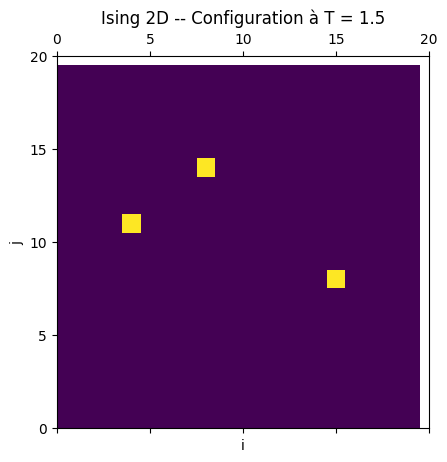

thermalization finished for T = 1.5544444444444445
thermalization finished for T = 1.6088888888888888
thermalization finished for T = 1.6633333333333333
thermalization finished for T = 1.7177777777777778
thermalization finished for T = 1.7722222222222221
thermalization finished for T = 1.8266666666666667
thermalization finished for T = 1.8811111111111112
thermalization finished for T = 1.9355555555555555
thermalization finished for T = 1.99
thermalization finished for T = 2.0
thermalization finished for T = 2.007594936708861
thermalization finished for T = 2.0151898734177216
thermalization finished for T = 2.0227848101265824
thermalization finished for T = 2.030379746835443
thermalization finished for T = 2.037974683544304
thermalization finished for T = 2.0455696202531644
thermalization finished for T = 2.053164556962025
thermalization finished for T = 2.060759493670886
thermalization finished for T = 2.0683544303797468
thermalization finished for T = 2.0759493670886076
thermalization

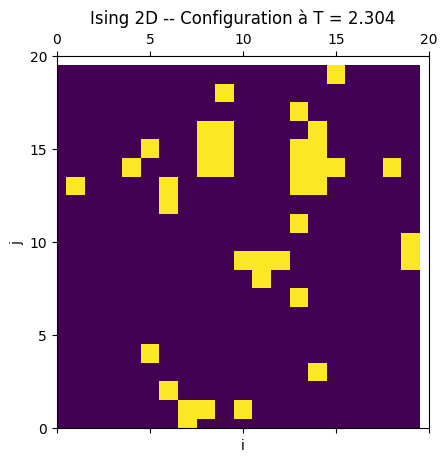

thermalization finished for T = 2.311392405063291
thermalization finished for T = 2.318987341772152
thermalization finished for T = 2.3265822784810126
thermalization finished for T = 2.3341772151898734
thermalization finished for T = 2.3417721518987342
thermalization finished for T = 2.349367088607595
thermalization finished for T = 2.356962025316456
thermalization finished for T = 2.3645569620253166
thermalization finished for T = 2.3721518987341774
thermalization finished for T = 2.379746835443038
thermalization finished for T = 2.387341772151899
thermalization finished for T = 2.3949367088607594
thermalization finished for T = 2.40253164556962
thermalization finished for T = 2.410126582278481
thermalization finished for T = 2.4177215189873418
thermalization finished for T = 2.4253164556962026
thermalization finished for T = 2.4329113924050634
thermalization finished for T = 2.440506329113924
thermalization finished for T = 2.448101265822785
thermalization finished for T = 2.45569620

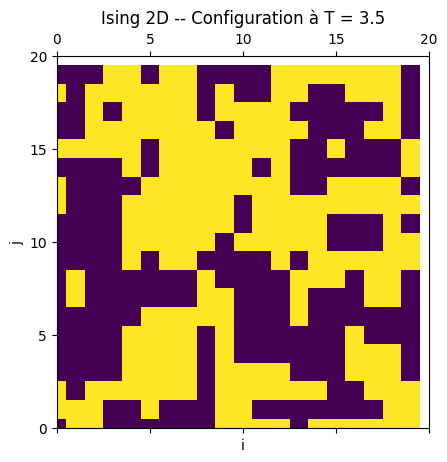

In [11]:
# tableau pour magnétisation moyenne
mag = np.zeros(len(T_list))

# tableau pour calculer la susceptibilité
mag2 = np.zeros(len(T_list))
X = np.zeros(len(T_list))

for indice, T in enumerate(T_list) :
    beta = 1./T

    lattice = init_lattice(l)

    #   THERMALISATION
    for t in range(0,1000) :
        for mc in range(0,n) :
            move()
    print("thermalization finished for T =", T)

    #  MESURES STATISTIQUES
    for t in range(0,200) :
        for mc in range(0, n*K):
            move()

        m = abs(magnetization(lattice))
        mag[indice] += m
        mag2[indice] += m*m

    mag[indice] /= 200
    mag2[indice] /= 200

    # susceptibilité χ = ( <m²> – <m>² ) * beta
    X[indice] = (mag2[indice] - mag[indice]*mag[indice]) * beta

    # VISUALISATION 1 fois sur 50
    if indice % 50 == 0 :
        plt.matshow(lattice)
        plt.xlabel("i")
        plt.ylabel("j")
        plt.title("Ising 2D -- Configuration à T = "+str(round(T,3)))
        plt.xlim(0,l)
        plt.ylim(0,l)
        plt.savefig("Ising2d_config_T"+str(round(T,3))+".png")
        plt.show()

---

## 5. Results and Physical Observations

In this section, we analyze the numerical data generated by the Metropolis algorithm. We begin with a qualitative visual inspection of the lattice states before moving to a quantitative analysis of thermodynamic variables.

### 5.1. Visual Analysis of Lattice Configurations

The visualization of the spin lattice at different temperatures provides an intuitive understanding of the competition between **magnetic coupling** (which favors order) and **thermal fluctuations** (which favor disorder).

#### A. Low Temperature Phase ($T = 1.5$)
In the first snapshot, we observe a highly ordered state. Almost all spins are aligned in the same direction (represented by the dominant dark purple color). Only a few isolated spins have flipped due to thermal noise, but they cannot form large clusters.
* **Physical state**: This is the **ferromagnetic phase**. The interaction energy $J$ dominates over the thermal energy $k_B T$, forcing the system into a state of spontaneous symmetry breaking.

#### B. Near-Critical Region ($T = 2.304$)
As we approach the theoretical critical temperature $T_c \approx 2.27$, the configuration changes drastically. We observe the formation of **clusters** of various sizes.
* **Correlation Length**: Notice how the "yellow" spins are no longer isolated but form interconnected structures. At the exact critical point, the correlation length $\xi$ (the typical size of these clusters) theoretically becomes infinite.
* **Critical Opalescence**: The system is highly "undecided," and large regions can flip simultaneously with very little energy cost.

#### C. High Temperature Phase ($T = 3.5$)
In the final snapshot, the lattice appears as a "sea of noise" with no discernible structure. The yellow and purple pixels are distributed almost randomly and evenly.
* **Physical state**: This is the **paramagnetic phase**. Thermal energy is now high enough to overcome the coupling constant $J$. The entropy of the system is maximized, and the net magnetization drops toward zero.

---

### 5.2. Magnetization and Susceptibility Analysis

The following plots represent the thermodynamic averages calculated over the range $T \in [1.5, 3.5]$.

#### A. Spontaneous Magnetization $\langle |m| \rangle$
The magnetization curve (left) characterizes the **order parameter** of the system.
* **For $T < 2.2$**: We observe a plateau where $\langle |m| \rangle \approx 1$. The interaction $J$ keeps the spins locked in a parallel alignment despite thermal agitation.
* **The "Kink"**: Between $T = 2.2$ and $T = 2.5$, the magnetization drops sharply. This rapid decrease is the signature of a **second-order phase transition**.
* **For $T > 2.5$**: The magnetization reaches a residual "noise" floor near zero. In an infinite system ($L \to \infty$), this would be exactly zero. On our $20 \times 20$ lattice, small finite-size effects and statistical noise remain.

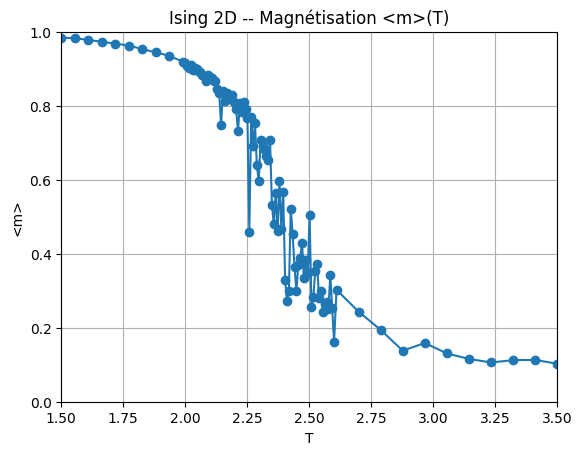

In [12]:
# COURBE MAGNÉTISATION
plt.plot(T_list, mag, marker='o')
plt.xlabel("T")
plt.ylabel("<m>")
plt.title("Ising 2D -- Magnétisation <m>(T)")
plt.xlim(T_list[0], T_list[-1])
plt.ylim(0., 1.)
plt.grid()
plt.savefig('Ising2d_L20_magnetization_curve.png')
plt.show()

#### B. Magnetic Susceptibility $\chi(T)$
The susceptibility curve (right) is perhaps the most revealing diagnostic tool for identifying the critical point.
* **The Critical Peak**: We observe a clear divergence (a sharp peak) centered around $T \approx 2.3$. This corresponds to the point where the system's state is most volatile; a tiny change in temperature or a small external field would cause a massive change in the spin configuration.
* **Numerical Estimation of $T_c$**: Based on the maximum of the peak, our simulation estimates $T_c \approx 2.3$. This is remarkably close to the theoretical value of **$2.269 \, J/k_B$**, especially considering the small lattice size ($20 \times 20$).

#### C. Discussion on Noise and Finite-Size Effects
You may notice that the curves are "jittery" near the peak. This is due to two main factors:
1.  **Critical Slowing Down**: Near $T_c$, the time it takes for the system to reach equilibrium (relaxation time) increases dramatically. Our 1000 thermalization steps and 200 measurements are pushed to their limits here.
2.  **Finite-Size Scaling**: In thermodynamics, phase transitions are strictly defined for the thermodynamic limit ($L \to \infty$). With $L=20$, the peak of $\chi$ is rounded and shifted slightly compared to the theoretical infinite-lattice result.

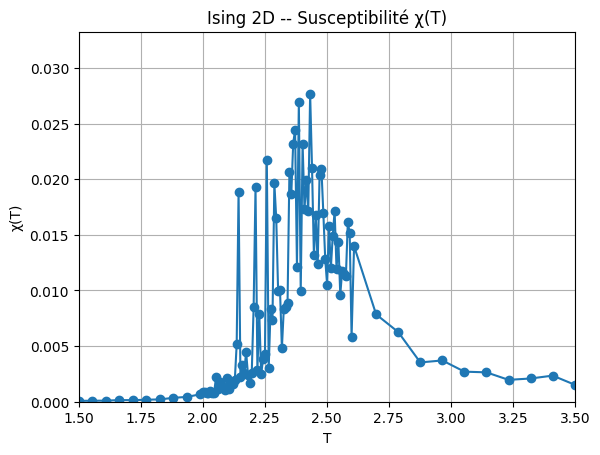

In [13]:
# COURBE SUSCEPTIBILITÉ
plt.plot(T_list, X, marker='o')
plt.xlabel("T")
plt.ylabel("χ(T)")
plt.title("Ising 2D -- Susceptibilité χ(T)")
plt.xlim(T_list[0], T_list[-1])
plt.ylim(0., max(X)*1.2)
plt.grid()
plt.savefig('Ising2d_L20_susceptibility_curve.png')
plt.show()

---

## 6. Conclusion

In this project, we successfully implemented a **Monte Carlo simulation** of the 2D Ising model using the **Metropolis-Hastings algorithm**. By exploring a range of temperatures around the theoretical critical point, we were able to numerically recover the signature of a second-order phase transition.

### Summary of Findings
* **Phase Transition**: Both qualitative (lattice snapshots) and quantitative (magnetization and susceptibility) results confirm the transition from a **ferromagnetic ordered state** at low temperatures to a **paramagnetic disordered state** at high temperatures.
* **Critical Temperature**: Our simulation yields a peak in magnetic susceptibility at $T \approx 2.3$. This is in excellent agreement with **Onsager's exact solution** ($T_c \approx 2.269 \, J/k_B$), especially given the relatively small lattice size of $20 \times 20$.
* **Fluctuation-Dissipation**: We effectively used the relationship between magnetization fluctuations and susceptibility to pinpoint the transition, demonstrating the power of statistical mechanics in numerical modeling.

### Critical Assessment of the Method
While the Metropolis algorithm is robust, we observed significant statistical "noise" and fluctuations near $T_c$. This highlights two major challenges in computational physics:
1.  **Critical Slowing Down**: Near the transition, the system's relaxation time diverges. The local flip updates of the Metropolis algorithm become less efficient at exploring the configuration space, as large clusters of spins are difficult to break or flip.
2.  **Finite-Size Effects**: On a $20 \times 20$ lattice, the phase transition is not as "sharp" as it would be in a macroscopic system. The susceptibility peak is slightly shifted and rounded due to the finite number of degrees of freedom.

Through this work, we have demonstrated that even a relatively simple stochastic model can capture the complex collective behavior of many-body systems, providing a window into the fascinating world of critical phenomena.
